<a href="https://colab.research.google.com/github/Kaweri05/sarcasm-detection/blob/main/Copy_of_sarcasm_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from urllib.parse import urlparse
from nltk.corpus import stopwords
import re
import nltk
from wordcloud import WordCloud
nltk.download("stopwords")
from sklearn.model_selection import train_test_split, RandomizedSearchCV, RepeatedStratifiedKFold
from sklearn.ensemble import RandomForestClassifier
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, roc_auc_score, recall_score, f1_score
from lightgbm import LGBMClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GRU, Embedding
from tensorflow.keras.optimizers import Adam,SGD,RMSprop
!pip install optuna
import optuna
import time
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.6 MB/s eta 0:00:00


In [ ]:
data = pd.read_json("/content/Sarcasm_Headlines_Dataset.json.zip", lines=True)
data.head()

,article_link,headline,is_sarcastic
0,https://www.huffingtonpost.com/entry/versace-b...,former versace store clerk sues over secret 'b...,0
1,https://www.huffingtonpost.com/entry/roseanne-...,the 'roseanne' revival catches up to our thorn...,0
2,https://local.theonion.com/mom-starting-to-fea...,mom starting to fear son's web series closest ...,1
3,https://politics.theonion.com/boehner-just-wan...,"boehner just wants wife to listen, not come up...",1
4,https://www.huffingtonpost.com/entry/jk-rowlin...,j.k. rowling wishes snape happy birthday in th...,0


In [ ]:
print("Null Values\n",data.isnull().sum())
print("\nData Shape: " , data.shape)

Null Values
 article_link    0
headline        0
is_sarcastic    0
dtype: int64

Data Shape:  (26709, 3)


In [ ]:
def find_num_words(data):
    wordlist = []
    splitting_list = data.str.split()
    for i in range(len(splitting_list)):
        for j in range(len(splitting_list[i])):
            wordlist.append(splitting_list[i][j])

    wordset = set(wordlist)

    print(len(wordset),len(wordlist))

find_num_words(data.headline)

36599 262972


In [ ]:
def find_num_words(data):
    wordlist = []
    splitting_list = data.str.split()
    for i in range(len(splitting_list)):
        for j in range(len(splitting_list[i])):
            wordlist.append(splitting_list[i][j])

    wordset = set(wordlist)

    print(len(wordset),len(wordlist))

find_num_words(data.headline)

36599 262972


is_sarcastic
0    14985
1    11724
Name: count, dtype: int64 



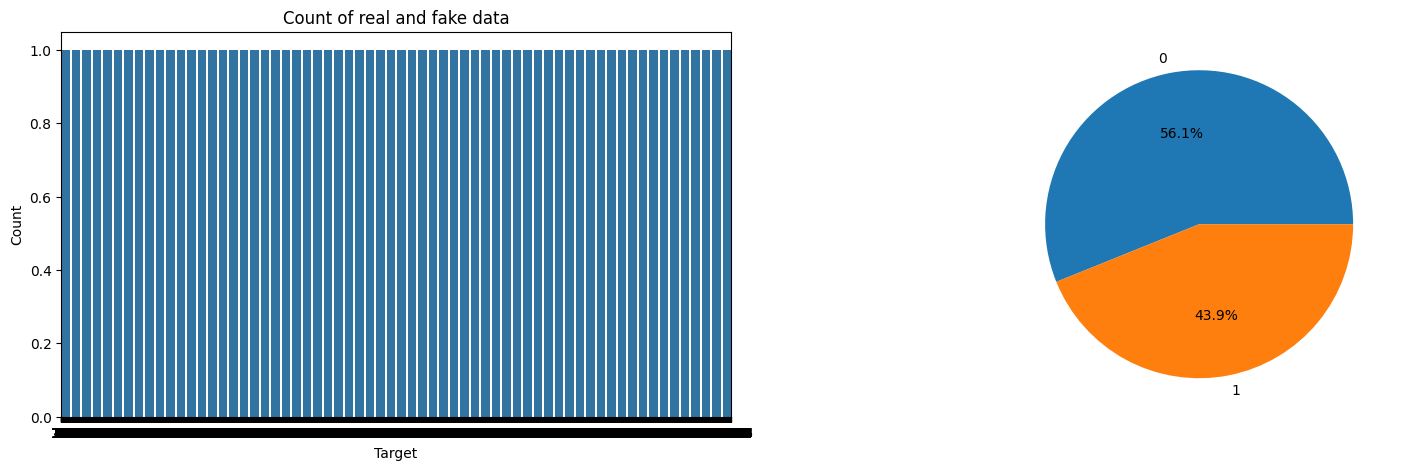

In [ ]:
print(data.is_sarcastic.value_counts() ,"\n")

fig, ax = plt.subplots(1,2, figsize=(19, 5))
f1 = sns.countplot(data.is_sarcastic, ax = ax[0]);
f1.set_title("Count of real and fake data")
f1.set_ylabel("Count")
f1.set_xlabel("Target")

f2 = plt.pie(data["is_sarcastic"].value_counts().values,explode=[0,0],labels=data.is_sarcastic.value_counts().index, autopct='%1.1f%%')
fig.show()

In [ ]:
def get_netloc(url):
    scheme, netloc, path, params, query, fragment = urlparse(url)
    return netloc

link = []
for i in range(len(data.article_link)):
    link.append(get_netloc(data.article_link[i]))

data["link"] = link

In [ ]:
data.link = data["link"].str.replace("local.theonion.com","www.theonion.com").replace("politics.theonion.com","www.theonion.com").replace("entertainment.theonion.com","www.theonion.com").replace("sports.theonion.com","www.theonion.com").replace("ogn.theonion.com","www.theonion.com")
data.link = data.link.str.replace('www.huffingtonpost.comhttp:','www.huffingtonpost.com').replace('www.huffingtonpost.comhttps:','www.huffingtonpost.com')
data.link.value_counts()

,count
link,
www.huffingtonpost.com,14985
www.theonion.com,11724


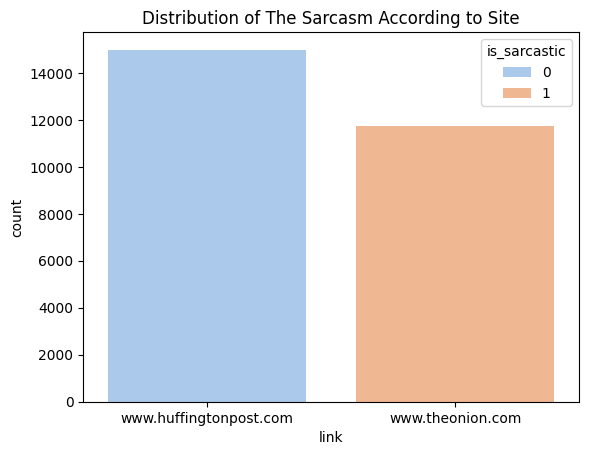

In [ ]:
ax = sns.countplot(x="link",  hue='is_sarcastic', data=data, palette="pastel")
plt.title("Distribution of The Sarcasm According to Site");

In [ ]:
#Removing punctiation marks
def remove_punctuations(text):
    return re.sub('\[[^\]]*\]', '', text)

#Removing special characters
def remove_specialchars(text):
    return re.sub("[^a-zA-Z]"," ",text)

# *** Fix Start ***
# Download the 'punkt_tab' resource for nltk.word_tokenize
nltk.download('punkt_tab', quiet=True)
# Download the 'wordnet' resource for lemmatization
nltk.download('wordnet', quiet=True)
# *** Fix End ***

#Removal of stopwords and lemmatization
def remove_stopwords_and_lemmatization(text):
    final_text = []
    text = text.lower()
    text = nltk.word_tokenize(text)

    for word in text:
        if word not in set(stopwords.words('english')):
            lemma = nltk.WordNetLemmatizer()
            word = lemma.lemmatize(word)
            final_text.append(word)
    return " ".join(final_text)

    #Total function
def cleaning(text):
    text = remove_punctuations(text)
    text = remove_specialchars(text)
    text = remove_stopwords_and_lemmatization(text)
    return text

data['headline']=data['headline'].apply(cleaning)

There are 1290917 words in the combination of all review.


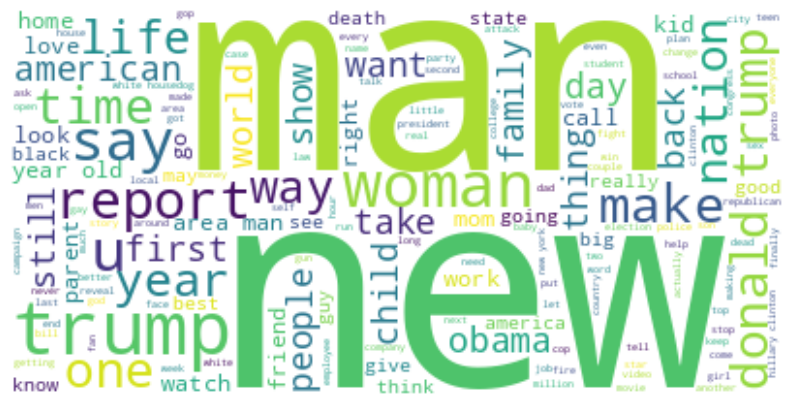

In [ ]:
text = " ".join(review for review in data.headline)
print ("There are {} words in the combination of all review.".format(len(text)))

# Generate a word cloud image
wordcloud = WordCloud(background_color="white").generate(text)

# Display the generated image:
# the matplotlib way:
plt.figure(figsize=(10,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [ ]:
data.head()

,article_link,headline,is_sarcastic,link
0,https://www.huffingtonpost.com/entry/versace-b...,former versace store clerk sue secret black co...,0,www.huffingtonpost.com
1,https://www.huffingtonpost.com/entry/roseanne-...,roseanne revival catch thorny political mood b...,0,www.huffingtonpost.com
2,https://local.theonion.com/mom-starting-to-fea...,mom starting fear son web series closest thing...,1,www.theonion.com
3,https://politics.theonion.com/boehner-just-wan...,boehner want wife listen come alternative debt...,1,www.theonion.com
4,https://www.huffingtonpost.com/entry/jk-rowlin...,j k rowling wish snape happy birthday magical way,0,www.huffingtonpost.com


In [ ]:
sentences = data["headline"].values.tolist()
target = data["is_sarcastic"].values.tolist()

In [ ]:
print(sentences[:2])
print(target[:2])

['former versace store clerk sue secret black code minority shopper', 'roseanne revival catch thorny political mood better worse']
[0, 0]


In [ ]:
num_words = 1000
tokenizer = Tokenizer(num_words=num_words)

tokenizer.fit_on_texts(sentences)
tokens = tokenizer.texts_to_sequences(sentences)

numTokens = [len(token) for token in tokens]
numTokens = np.array(numTokens)
print("Tokens'mean",np.mean(numTokens))
print("Max", np.max(numTokens))
print("Argmax", np.argmax(numTokens))

Tokens'mean 3.6754277584334867
Max 13
Argmax 2498


In [ ]:
#Longest one
sentences[7302]

'target pull sponsorship publicly ignored syrian conflict'

In [ ]:
ax_tokens = int(np.mean(numTokens) + 2*np.std(numTokens))
print("Calculated maximum number of tokens :",ax_tokens)
print("What percentage of the data fits this average? :",np.sum(numTokens < ax_tokens) / len(numTokens))

Calculated maximum number of tokens : 7
What percentage of the data fits this average? : 0.9180426073608147


In [ ]:
padding_data = pad_sequences(tokens, maxlen=ax_tokens)
print(padding_data.shape)
print(len(target))

(26709, 7)
26709


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(padding_data, data.is_sarcastic, random_state=1, test_size=0.15, stratify=data.is_sarcastic)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, random_state=1, test_size=0.1, stratify=y_train)

In [ ]:
def objective(trial):
    # Parameters
    L2 = trial.suggest_float("l", 1e-5, 1e-2, log=True)
    EMBEDDING_SIZE = trial.suggest_int("embedding_size", 10, 50, step=10)
    BATCH_SIZE = trial.suggest_int("batch_size", 16, 64, step=8)
    EPOCHS = trial.suggest_int("epochs", 10,30, step=10)
    LR = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)
    OPT = trial.suggest_categorical("optimizer", [Adam, SGD, RMSprop])


    # Model
    """base_model = model(include_top=False, weights="imagenet", pooling="max")
    for layer in base_model.layers:
        layer.trainable = False
    x = base_model.output
    predictions = Dense(train_generator.num_classes, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=predictions)"""
    model = Sequential()
    model.add(Embedding(input_dim = num_words,
                        output_dim=EMBEDDING_SIZE,
                        input_length=ax_tokens, # Changed max_tokens to ax_tokens
                        name='embedding_layer'))

    model.add(GRU(units=128, return_sequences=True, kernel_regularizer = tf.keras.regularizers.l2(l2=L2)))
    model.add(GRU(units=64,return_sequences=True, kernel_regularizer = tf.keras.regularizers.l2(l2=L2)))
    model.add(GRU(units=32))
    model.add(Dense(16, activation="relu"))
    model.add(Dense(1, activation='sigmoid'))


    model.compile(optimizer=OPT(learning_rate=LR), loss='binary_crossentropy', metrics=['accuracy'])
    H = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=EPOCHS, batch_size=BATCH_SIZE)

    val_loss, val_acc = model.evaluate(X_test,y_test)

    return val_loss # optuna değerlendirmesini en küçük değere göre yapıyor o yüzden loss döndürdüm. Accuracy döndürdüğümde acc büyüdükçe bunu kötü bir şeymiş gibi algıladı.


# Default Sampler is Tree-structured Parzen Estimator algorithm

study = optuna.create_study()
start = time.time()
study.optimize(objective, n_trials=5)
end = time.time()


[I 2026-03-29 15:45:05,889] A new study created in memory with name: no-name-ffa7ff86-6ded-4ec9-b8a3-93f1b5e859a6


Epoch 1/30
511/511 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.5611 - loss: 1.3051 - val_accuracy: 0.5610 - val_loss: 1.3026
Epoch 2/30
511/511 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.5611 - loss: 1.3007 - val_accuracy: 0.5610 - val_loss: 1.2989
Epoch 3/30
511/511 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.5611 - loss: 1.2975 - val_accuracy: 0.5610 - val_loss: 1.2962
Epoch 4/30
511/511 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.5611 - loss: 1.2951 - val_accuracy: 0.5610 - val_loss: 1.2941
Epoch 5/30
511/511 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.5611 - loss: 1.2931 - val_accuracy: 0.5610 - val_loss: 1.2923
Epoch 6/30
511/511 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.5611 - loss: 1.2914 - val_accuracy: 0.5610 - val_loss: 1.2905
Epoch 7/30
511/511 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.5611 - loss: 1.2896 - val_accuracy: 0.5610 - val_loss: 1.2888
Epoch 8/30
511/511 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.5611 - loss: 1.2879 - 

[I 2026-03-29 15:52:32,822] Trial 0 finished with value: 1.2514171600341797 and parameters: {'l': 0.003197552783729363, 'embedding_size': 20, 'batch_size': 40, 'epochs': 30, 'learning_rate': 0.00042434949268604845, 'optimizer': <class 'keras.src.optimizers.sgd.SGD'>}. Best is trial 0 with value: 1.2514171600341797.


Epoch 1/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - accuracy: 0.5610 - loss: 0.7531 - val_accuracy: 0.5610 - val_loss: 0.7523
Epoch 2/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.5611 - loss: 0.7517 - val_accuracy: 0.5610 - val_loss: 0.7510
Epoch 3/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 26s 44ms/step - accuracy: 0.5611 - loss: 0.7505 - val_accuracy: 0.5610 - val_loss: 0.7500
Epoch 4/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.5611 - loss: 0.7496 - val_accuracy: 0.5610 - val_loss: 0.7492
Epoch 5/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.5611 - loss: 0.7489 - val_accuracy: 0.5610 - val_loss: 0.7486
Epoch 6/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.5611 - loss: 0.7484 - val_accuracy: 0.5610 - val_loss: 0.7482
Epoch 7/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.5611 - loss: 0.7481 - val_accuracy: 0.5610 - val_loss: 0.7479
Epoch 8/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.5611 - loss: 0.7478 - 

[I 2026-03-29 15:56:57,612] Trial 1 finished with value: 0.7471281290054321 and parameters: {'l': 0.00027359467049862434, 'embedding_size': 40, 'batch_size': 56, 'epochs': 20, 'learning_rate': 0.00013843356451063277, 'optimizer': <class 'keras.src.optimizers.sgd.SGD'>}. Best is trial 1 with value: 0.7471281290054321.


...

[I 2026-03-29 16:11:36,927] Trial 2 finished with value: 1.2282966375350952 and parameters: {'l': 0.0030057448444908686, 'embedding_size': 30, 'batch_size': 16, 'epochs': 30, 'learning_rate': 0.0003152349965805229, 'optimizer': <class 'keras.src.optimizers.sgd.SGD'>}. Best is trial 1 with value: 0.7471281290054321.


Epoch 1/10
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.5609 - loss: 0.6886 - val_accuracy: 0.5610 - val_loss: 0.6880
Epoch 2/10
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.5611 - loss: 0.6879 - val_accuracy: 0.5610 - val_loss: 0.6880
Epoch 3/10
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 23s 18ms/step - accuracy: 0.5611 - loss: 0.6880 - val_accuracy: 0.5610 - val_loss: 0.6880
Epoch 4/10
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 24s 18ms/step - accuracy: 0.5611 - loss: 0.6879 - val_accuracy: 0.5610 - val_loss: 0.6881
Epoch 5/10
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 25s 19ms/step - accuracy: 0.5611 - loss: 0.6879 - val_accuracy: 0.5610 - val_loss: 0.6878
Epoch 6/10
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.5611 - loss: 0.6879 - val_accuracy: 0.5610 - val_loss: 0.6879
Epoch 7/10
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.5611 - loss: 0.6879 - val_accuracy: 0.5610 - val_loss: 0.6879
Epoch 8/10
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - accuracy: 0.5611 -

[I 2026-03-29 16:16:17,228] Trial 3 finished with value: 0.6876518726348877 and parameters: {'l': 1.2938205136687714e-05, 'embedding_size': 10, 'batch_size': 16, 'epochs': 10, 'learning_rate': 0.005198883787208904, 'optimizer': <class 'keras.src.optimizers.sgd.SGD'>}. Best is trial 3 with value: 0.6876518726348877.


Epoch 1/30
511/511 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.6876 - loss: 0.5899 - val_accuracy: 0.7380 - val_loss: 0.5300
Epoch 2/30
511/511 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - accuracy: 0.7500 - loss: 0.5081 - val_accuracy: 0.7424 - val_loss: 0.5306
Epoch 3/30
511/511 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.7687 - loss: 0.4829 - val_accuracy: 0.7525 - val_loss: 0.5152
Epoch 4/30
511/511 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.7768 - loss: 0.4677 - val_accuracy: 0.7512 - val_loss: 0.5182
Epoch 5/30
511/511 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.7829 - loss: 0.4559 - val_accuracy: 0.7517 - val_loss: 0.5122
Epoch 6/30
511/511 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.7895 - loss: 0.4456 - val_accuracy: 0.7490 - val_loss: 0.5152
Epoch 7/30
511/511 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.7977 - loss: 0.4358 - val_accuracy: 0.7472 - val_loss: 0.5716
Epoch 8/30
511/511 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.8052 - loss: 0.4270 - 

[I 2026-03-29 16:23:54,807] Trial 4 finished with value: 1.1487064361572266 and parameters: {'l': 4.256109449850995e-05, 'embedding_size': 40, 'batch_size': 40, 'epochs': 30, 'learning_rate': 0.005179373678310993, 'optimizer': <class 'keras.src.optimizers.rmsprop.RMSprop'>}. Best is trial 3 with value: 0.6876518726348877.


In [ ]:
best_params = study.best_params
print(best_params)
print("model took %0.2f seconds to train" % (end - start))

{'l': 1.2938205136687714e-05, 'embedding_size': 10, 'batch_size': 16, 'epochs': 10, 'learning_rate': 0.005198883787208904, 'optimizer': <class 'keras.src.optimizers.sgd.SGD'>}
model took 2328.92 seconds to train


In [ ]:
EMBEDDING_SIZE = 40

model = Sequential()
model.add(Embedding(input_dim = num_words,
                    output_dim=EMBEDDING_SIZE,
                    input_length=ax_tokens,
                    name='embedding_layer'))
model.add(GRU(units=128, return_sequences=True, kernel_regularizer = tf.keras.regularizers.l2(l2=1.367675698620851e-05)))
model.add(GRU(units=64,return_sequences=True, kernel_regularizer = tf.keras.regularizers.l2(l2=1.367675698620851e-05)))
model.add(GRU(units=32))
#model.add(Dense(16, activation="relu"))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_layer (Embedding)     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_18 (GRU)                    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_19 (GRU)                    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_20 (GRU)                    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss="binary_crossentropy", optimizer = RMSprop(learning_rate=8.74355057651944e-05), metrics=["accuracy"])
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=30, batch_size=40)

Epoch 1/30
511/511 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.5607 - loss: 0.6882 - val_accuracy: 0.5610 - val_loss: 0.6855
Epoch 2/30
511/511 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.5888 - loss: 0.6713 - val_accuracy: 0.6649 - val_loss: 0.6386
Epoch 3/30
511/511 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.6961 - loss: 0.5859 - val_accuracy: 0.7111 - val_loss: 0.5719
Epoch 4/30
511/511 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - accuracy: 0.7246 - loss: 0.5429 - val_accuracy: 0.7169 - val_loss: 0.5498
Epoch 5/30
511/511 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - accuracy: 0.7418 - loss: 0.5195 - val_accuracy: 0.7257 - val_loss: 0.5370
Epoch 6/30
511/511 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - accuracy: 0.7482 - loss: 0.5063 - val_accuracy: 0.7292 - val_loss: 0.5283
Epoch 7/30
511/511 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.7558 - loss: 0.4982 - val_accuracy: 0.7327 - val_loss: 0.5251
Epoch 8/30
511/511 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.7577 - loss: 0.4938 - 

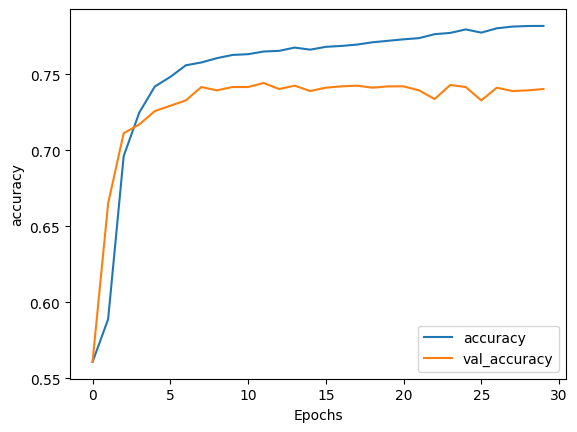

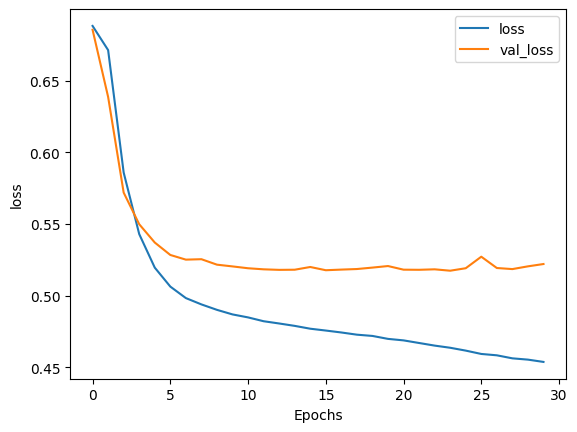

In [ ]:
import matplotlib.pyplot as plt


def plot_graphs(history, string):
    plt.plot(history.history[string])
    plt.plot(history.history['val_'+string])
    plt.xlabel("Epochs")
    plt.ylabel(string)
    plt.legend([string, 'val_'+string])
    plt.show()

plot_graphs(history, 'accuracy')
plot_graphs(history, 'loss')